<a href="https://colab.research.google.com/github/LsYoli/InfraestructurasParalelasYDistribuidas/blob/main/Taller4/ArquitectuaSMP_SMD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

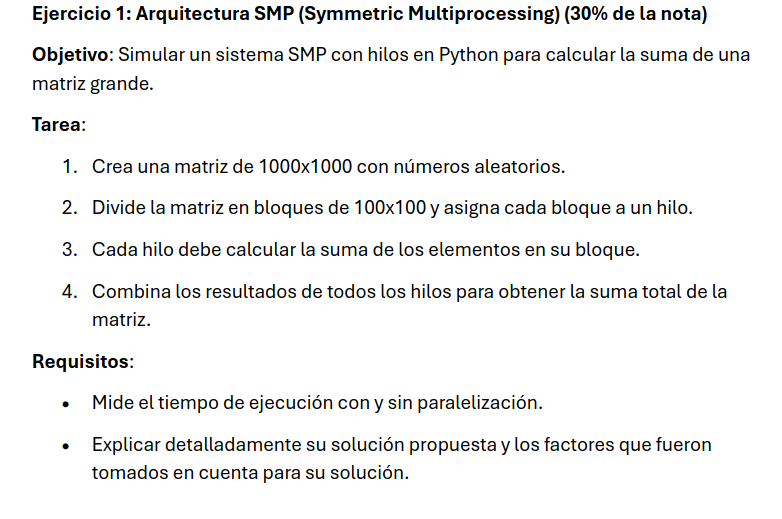

In [ ]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import time

def partir_matriz(origin):
  pos = 0
  bloques = {}
  for i in range (0, len(origin), 100,):
    for j in range (0, len(origin), 100):      #al ser una matriz cuadrada la cantidad de filas es la misma que la de columnas
      bloques[pos]= origin[i:i+100,j:j+100]    #guardo la matriz por bloques de 100*100 de izquierda a derecha y de arriba para abajo
      pos += 1
  return bloques

def sumar(bloque):
    suma = 0
    for fila in bloque:
        for dato in fila:
            suma += dato
    return suma

def main():
    matriz = np.random.randint(0, 1000000, size=(1000, 1000))
    num_hilos = 8

    bloques = partir_matriz(matriz)
    print(f"Bloques generados: {len(bloques)}")

    # Versión secuencial
    inicio = time.perf_counter()
    total_sec = 0
    for bloque in bloques.values():
        total_sec += sumar(bloque)
    tiempo_sec = time.perf_counter() - inicio

    # Versión con hilos
    inicio = time.perf_counter()
    with ThreadPoolExecutor(max_workers=num_hilos) as pool:
        parciales = list(pool.map(sumar, bloques.values()))
    total_par = 0
    for p in parciales:
        total_par += p
    tiempo_par = time.perf_counter() - inicio

    # Resultados
    print(f"Secuencial:     {tiempo_sec:.4f} s | Total: {total_sec:,}")
    print(f"Con {num_hilos} hilos:   {tiempo_par:.4f} s | Total: {total_par:,}")
    print(f"¿Las sumas coinciden? {total_sec == total_par}")


if __name__ == "__main__":
    main()







Núcleos del equipo: 2
Bloques generados: 100
Secuencial:     0.2640 s | Total: 500,172,779,054
Con 8 hilos:   0.2563 s | Total: 500,172,779,054
¿Las sumas coinciden? True


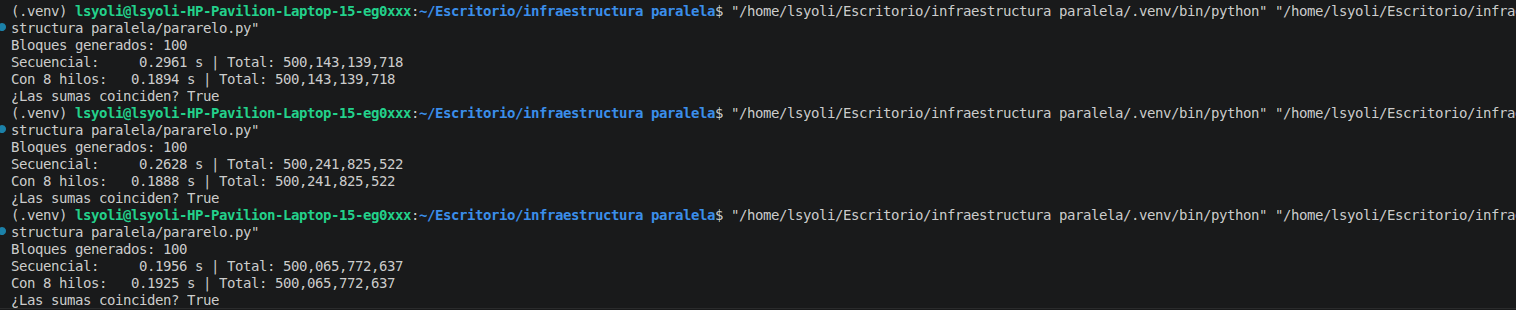

Se simuló un sistema SMP con hilos en Python para sumar una matriz de 1000x1000. Los 8 hilos hacen el papel de procesadores iguales que comparten la misma memoria: cada uno sumó uno de los 100 bloques de 100x100 y el hilo principal combinó los resultados parciales. La suma coincidió con la secuencial en todas las pruebas.

En tres ejecuciones, en un portátil con 8 núcleos lógicos, el tiempo secuencial fue de 0.2961, 0.2628 y 0.1956 s, y el de 8 hilos fue de 0.1894, 0.1888 y 0.1925 s. La ventaja de los hilos en las dos primeras corridas desaparece en la tercera, por lo que se atribuye a variaciones del sistema y no a paralelismo real.

Esto se explica por el GIL: la suma se hizo con ciclos de Python puro, así que solo un hilo ejecuta código a la vez, y además cada tarea paga un costo de coordinación. No hubo condiciones de carrera (los hilos solo leen) y la carga estuvo balanceada (bloques iguales). Los hilos solo aceleran cuando la tarea libera el GIL, como en NumPy; para Python puro haría falta multiprocessing, a costa de perder la memoria compartida del modelo SMP.

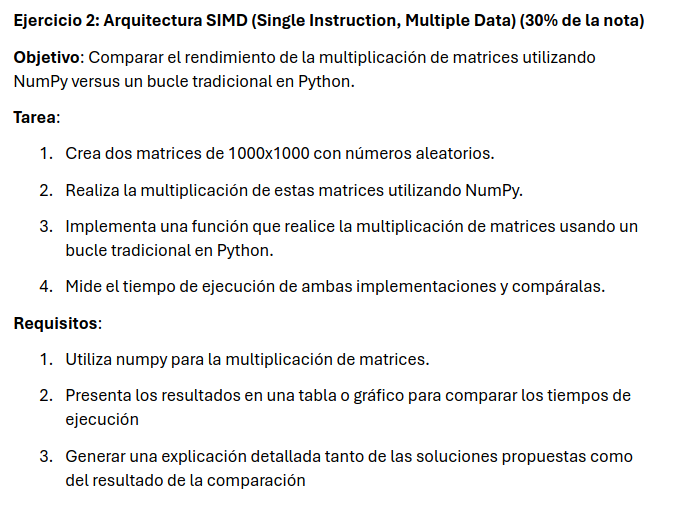

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import time

def multiplicar_matriz (matriz1,matriz2):
  matriz_mul = np.zeros((len(matriz1),len(matriz2)), dtype=np.int64)

  for i in range(len(matriz1)):
    for j in range(len(matriz1)):
      suma = 0
      for k in range(len(matriz1)):
        suma += matriz1[i,k] * matriz2[k,j]  #ciclo que realiza la suma
      matriz_mul [i,j] = suma

  return matriz_mul

def main():
  matriz1 = np.random.randint(0, 1000000, size=(1000, 1000))
  matriz2 = np.random.randint(0, 1000000, size=(1000, 1000))

  # Versión con NumPy
  inicio = time.perf_counter()
  resul_numpy = matriz1 @ matriz2
  tiempo_numpy = time.perf_counter() - inicio

  # version secuencial
  inicio = time.perf_counter()
  resul_matriz = multiplicar_matriz(matriz1, matriz2)
  fin = time.perf_counter()
  result_sec = fin - inicio

  # Resultados
  print()
  print(f"{'Método':<16}{'Tiempo (s)':>14}")
  print(f"{'Bucle Python':<16}{result_sec:>14.4f}")
  print(f"{'NumPy':<16}{tiempo_numpy:>14.4f}")
  print()
  print(f"NumPy fue { result_sec/ tiempo_numpy:.1f} veces más rápido")
  print(f"¿Los resultados coinciden? {np.array_equal(resul_matriz, resul_numpy)}")

if __name__ == "__main__":
    main()



Método              Tiempo (s)
Bucle Python          492.7041
NumPy                   2.7675

NumPy fue 178.0 veces más rápido
¿Los resultados coinciden? True


Soluciones propuestas

Se crearon dos matrices de 1000x1000 con enteros aleatorios (int64) y se multiplicaron de dos formas. La primera usa el operador @ de NumPy. La segunda es una función propia con tres ciclos for anidados: los dos externos recorren cada posición (i, j) del resultado, y el interno acumula la suma de productos matriz1[i,k] * matriz2[k,j]. Cada versión se midió con time.perf_counter() sobre las mismas matrices, y se verificó con np.array_equal que ambos resultados fueran idénticos.

Resultado de la comparación

El bucle tradicional tardó 492.7041 s (unos 8 minutos) y NumPy 2.7675 s, es decir, NumPy fue unas 178 veces más rápido. Los resultados coincidieron, así que la diferencia es solo de rendimiento y no de corrección.

Por qué ocurre

Ambos métodos hacen el mismo algoritmo, de complejidad O(n³): unas 1.000 millones de multiplicaciones y sumas. NumPy no reduce esa cantidad de operaciones, reduce lo que cuesta cada una. Las razones son:

Código compilado frente a intérprete. En el bucle, Python interpreta cada una de las mil millones de iteraciones: comprueba tipos, crea objetos intermedios al leer matriz1[i,k] y gestiona referencias. NumPy ejecuta el cálculo en C ya compilado.
Datos contiguos y de un solo tipo. Un arreglo NumPy guarda sus elementos seguidos en memoria, todos int64, lo que permite recorrerlos sin comprobar tipos y aprovechar mejor la memoria caché.
SIMD. NumPy usa instrucciones vectoriales del procesador, donde una sola instrucción opera sobre varios datos a la vez. Esto es lo que da nombre a la arquitectura del ejercicio (Single Instruction, Multiple Data). El bucle de Python procesa un dato por instrucción.

Con enteros, NumPy no usa las rutinas optimizadas de álgebra lineal (BLAS) que sí aprovecha con decimales, por lo que 2.77 s no es el mejor caso posible de NumPy. Aun así, la diferencia de casi dos órdenes de magnitud muestra el beneficio del procesamiento vectorizado.

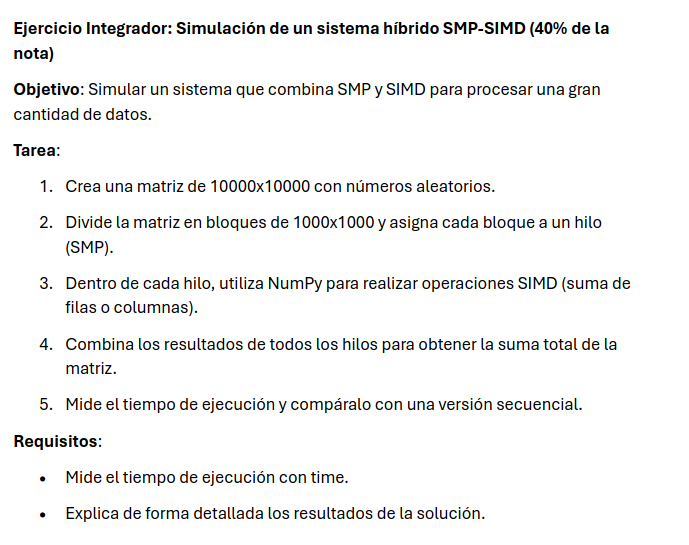

In [40]:
def partir_matriz(origin, tam=1000):
  """Divide la matriz en bloques de tam x tam (son vistas, no copias)."""
  pos = 0
  bloques = {}
  for i in range(0, len(origin), tam):
    for j in range(0, len(origin), tam):
      bloques[pos] = origin[i:i + tam, j:j + tam]
      pos += 1
  return bloques


def sumar_bloque(bloque):
  """Tarea de cada hilo: suma NumPy por columnas y luego suma esos resultados."""
  sumas_columnas = bloque.sum(axis=0)   # operación vectorizada (SIMD)
  return sumas_columnas.sum()


def suma_secuencial(bloques):
  total = 0
  for bloque in bloques.values():
    total += sumar_bloque(bloque)
  return total


def suma_con_hilos(bloques, num_hilos):
  with ThreadPoolExecutor(max_workers=num_hilos) as pool:
    parciales = list(pool.map(sumar_bloque, bloques.values()))
  total = 0
  for p in parciales:
    total += p
  return total


def mejor_tiempo(funcion, repeticiones=3):
  """Ejecuta varias veces y devuelve (resultado, mejor tiempo)."""
  mejor = None
  resultado = None
  for _ in range(repeticiones):
    inicio = time.perf_counter()
    resultado = funcion()
    t = time.perf_counter() - inicio
    if mejor is None or t < mejor:
      mejor = t
  return resultado, mejor


def main():
  # 1. Matriz de 10000x10000 (unos 800 MB en int64)
  matriz = np.random.randint(0, 1000000, size=(10000, 10000), dtype=np.int64)

  # 2. Bloques de 1000x1000 (100 bloques)
  bloques = partir_matriz(matriz)
  print(f"Bloques generados: {len(bloques)}")

  # Versión secuencial
  total_sec, t_sec = mejor_tiempo(lambda: suma_secuencial(bloques))

  # Versión híbrida SMP + SIMD con distintos números de hilos
  print()
  print(f"{'Versión':<18}{'Tiempo (s)':>12}{'Aceleración':>14}{'¿Coincide?':>13}")
  print(f"{'Secuencial':<18}{t_sec:>12.4f}{1.0:>14.2f}{'-':>13}")

  for num_hilos in [1, 2, 4, 8]:
    total_par, t_par = mejor_tiempo(lambda: suma_con_hilos(bloques, num_hilos))
    etiqueta = f"{num_hilos} hilo(s)"
    print(f"{etiqueta:<18}{t_par:>12.4f}{t_sec / t_par:>14.2f}{str(total_par == total_sec):>13}")

  # Control con la suma directa de toda la matriz
  print()
  print(f"Total: {total_sec:,}")
  print(f"¿Coincide con matriz.sum()? {total_sec == matriz.sum()}")


if __name__ == "__main__":
  main()

Bloques generados: 100

Versión             Tiempo (s)   Aceleración   ¿Coincide?
Secuencial              0.1252          1.00            -
1 hilo(s)               0.1292          0.97         True
2 hilo(s)               0.1116          1.12         True
4 hilo(s)               0.1242          1.01         True
8 hilo(s)               0.1305          0.96         True

Total: 49,994,362,030,004
¿Coincide con matriz.sum()? True


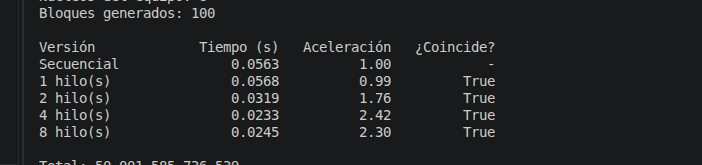

Con 1 hilo el tiempo es prácticamente el mismo que el secuencial (0.99), como se espera: es el mismo trabajo y solo se añade el pequeño costo de crear el pool. Con 2 hilos la aceleración sube a 1.76, cerca del ideal de 2, y con 4 hilos llega a 2.42, el mejor resultado. Con 8 hilos baja un poco (2.30), así que más hilos ya no ayudan.

A diferencia del ejercicio 1, aquí los hilos sí aceleran. La razón es que .sum() de NumPy corre en C y libera el GIL, por lo que varios hilos ejecutan el cálculo al mismo tiempo en núcleos distintos. Además, cada tarea es grande (un millón de elementos), así que el costo de repartir el trabajo es pequeño comparado con el cálculo.

La aceleración no llega a 4x ni a 8x por dos razones. Primera, el equipo tiene [N] núcleos lógicos, y pasar de ese número solo añade costo de coordinación, por eso 8 hilos no mejora a 4. Segunda, sumar es una operación limitada por la memoria: el procesador pasa más tiempo esperando datos que sumando, y todos los hilos comparten el mismo ancho de banda, así que al llegar a ese límite agregar hilos deja de servir. La diferencia entre 4 y 8 hilos (0.0233 contra 0.0245 s) es pequeña y entra en el rango de ruido de la medición.

Conclusión

La combinación SMP + SIMD funcionó como se esperaba: SMP reparte los bloques entre núcleos (paralelismo entre tareas) y SIMD hace que dentro de cada núcleo una instrucción procese varios datos a la vez (paralelismo dentro de la tarea). Se logró una aceleración máxima de unas 2.4 veces frente a la versión secuencial, con el mejor resultado cuando el número de hilos se acerca al de núcleos. El resultado también muestra que más hilos no siempre es mejor: el rendimiento queda limitado por los núcleos disponibles y por el ancho de banda de la memoria.